<a href="https://colab.research.google.com/github/sofialindner/ntl-urban-expansion-mapping/blob/develop/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import geopandas as gpd

# Lê shapefile
cities = gpd.read_file("LITORAL_SC_REPROJETADO.shp")

# Normaliza tipo de cada atributo
cities["CD_MUN"] = cities["CD_MUN"].astype(int)
cities["NM_MUN"] = cities["NM_MUN"].astype(str)

# Indexa dados de cada município por código
cities_by_code = {
    row["CD_MUN"]: {
        "name": row["NM_MUN"],
        "geometry": row.geometry,
        "row": row
    }
    for _, row in cities.iterrows()
}

In [45]:
# Intervalo de anos
YEARS = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]

# Intervalo de meses
MONTHS = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]

# Lista de cidades separados por região
CITIES_BY_REGION = {
  "itajai": [
    4202008,
    4202107,
    4202453,
    4208203,
    4208302,
    4211306,
    4212502,
    4212809,
    4213500,
    4218004,
  ],
  "florianopolis": [
    4202305,
    4205407,
    4205704,
    4206009,
    4207304,
    4211900,
    4212304,
    4216602,
  ],
  "ararangua": [4201406, 4201950, 4202073, 4212254],
  "tubarao": [4208807, 4209409],
  "joinville": [4201307, 4202057, 4208450, 4216206],
  "criciuma": [4220000],
}

In [43]:
import rasterio
from rasterio.mask import mask
import numpy as np
from glob import glob

pixel_series_by_city = {}

for region_name, city_codes in CITIES_BY_REGION.items():

    print(f"\nREGIÃO: {region_name}")

    for year in YEARS:
      image_paths = sorted(
          glob(f"{region_name}/{year}/*.tif", recursive=True)
      )

      for path in image_paths:
          print(path)

          # Abre raster da região
          with rasterio.open(path) as src:

              for city_code in city_codes:
                  city = cities_by_code[city_code]

                  # Extrai atributos do município
                  city_name = city["name"]
                  city_geometry = city["geometry"]

                  print(f"  Município: {city_name}")

                  # Inicializa estrutura da cidade
                  if city_code not in pixel_series_by_city:
                      pixel_series_by_city[city_code] = {}

                  # Recorta raster pelo município
                  out_image, out_transform = mask(
                      src,
                      [city_geometry],
                      crop=True
                  )

                  img = out_image[0]

                  # Recorta background
                  valid_mask = ~np.isnan(img)
                  rows, cols = np.where(valid_mask)

                  for row, col in zip(rows, cols):
                      value = img[row, col]

                      if np.isnan(value):
                          continue

                      # Coordenadas geográficas reais
                      x, y = rasterio.transform.xy(
                          out_transform,
                          row,
                          col
                      )

                      # Cria chave do pixel a partir das coordenadas
                      key = (x, y)

                      # Armazena luminosidade
                      if key not in pixel_series_by_city[city_code]:
                          pixel_series_by_city[city_code][key] = []

                      pixel_series_by_city[city_code][key].append(
                          float(value)
                      )


REGIÃO: itajai

REGIÃO: florianopolis

REGIÃO: ararangua

REGIÃO: tubarao

REGIÃO: joinville

REGIÃO: criciuma


In [ ]:
from sklearn.linear_model import LinearRegression

def pixel_linear_trend(serie):
    y = np.array(serie)

    # Filtra valores NaN
    valid = ~np.isnan(y)

    y = y[valid]

    # Não tenta calcular regressão para séries pequenas
    if len(y) < 2:
        return 0.0

    X = np.arange(len(y)).reshape(-1,1)

    model = LinearRegression()
    model.fit(X, y)

    return model.coef_[0]

In [ ]:
from dataclasses import dataclass

# Calcula features para cada pixel
pixel_features = {}

for key, serie in pixel_series_by_city.items():
  pixel_features[key] = {
      'mean': np.mean(serie),
      'var': np.var(serie),
      'max': np.max(serie),
      'min': np.min(serie),
      'linear_trend': pixel_linear_trend(serie),
      'position': key
  }


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Transforma em dataframe
df = pd.DataFrame(pixel_features.values())
X = df[['mean', 'var', 'max', 'min', 'linear_trend']]

# Padroniza escala entre features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Treina modelo KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=1,
    n_init='auto'
)

clusters = kmeans.fit_predict(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


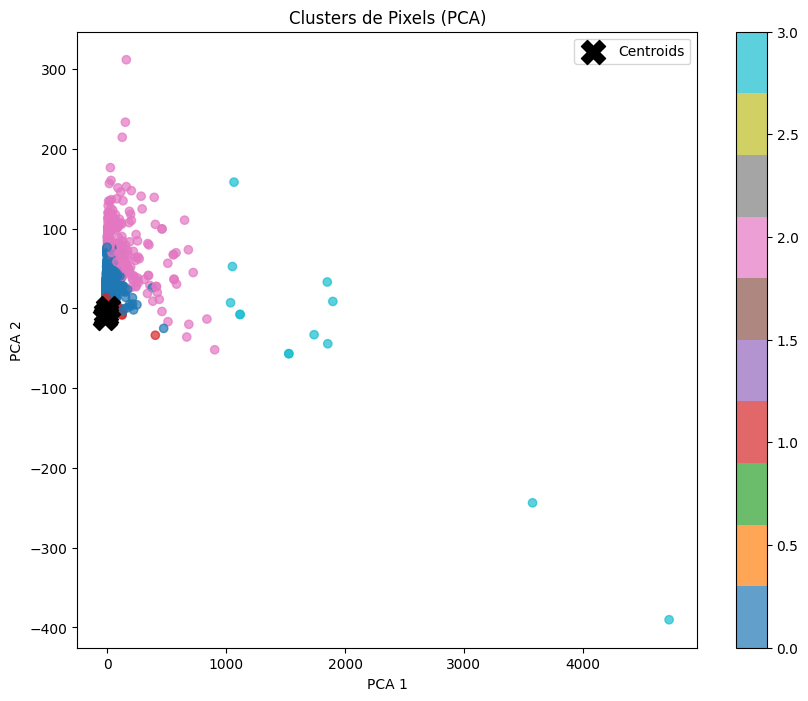

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='tab10',
    alpha=0.7
)

# Centróides transformados
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters de Pixels (PCA)')
plt.legend()
plt.colorbar(scatter)

plt.show()